First, I loaded the required libraries for handling spatial and tabular data, then set my working directory to the folder containing my GIS files. After that, I imported the ward boundary dataset from a GeoJSON file. 

In [102]:
import os
import geopandas as gpd
import pandas as pd
os.chdir("/Users/asherscott/Desktop/QSTUFF")

In [104]:
wards = gpd.read_file("Wards_from_2022.geojson")

Next I loaded the required spatial and tabular libraries. Then I imported the ACS social characteristics dataset and the DC ward boundary shapefile, keeping only the ward identifier and geometry columns to simplify the spatial layer. After that, I defined a dictionary of ADA-related infrastructure datasets (bus stops, curb ramps, audible pedestrian signals, and metro stations) to make it easier to loop through and process each dataset consistently in later analysis.

In [108]:
acs = gpd.read_file("ACS_5-Year_Social_Characteristics_DC_Ward.csv")
wards = gpd.read_file("Wards_from_2022.geojson")[["WARD", "geometry"]]

datasets = {
    "bus": "ADA_Bus_Stop.csv",
    "curb": "ADA_Curb_Ramp.csv",
    "aps": "ADA_Audible_Pedestrian_Signals.csv",
    "metro": "Metro_Stations_(Regional).csv"
}

I created a results dictionary to store outputs from each dataset and wrote a function to automatically detect longitude and latitude columns. I then looped through each ADA dataset, converted it into a GeoDataFrame, and aligned it with the ward boundaries. After performing a spatial join to assign each point to a ward, I calculated either total sidewalk length or feature counts depending on the dataset and stored the results incase I want to use it later.

In [92]:
results = {}

def get_coords(df):
    lon_options = ["LONGITUDE", "Longitude", "LON", "X"]
    lat_options = ["LATITUDE", "Latitude", "LAT", "Y"]

    lon_col = next((c for c in lon_options if c in df.columns), None)
    lat_col = next((c for c in lat_options if c in df.columns), None)

    if lon_col and lat_col:
        return df[lon_col], df[lat_col]

    raise ValueError("No coordinate columns found")

for name, file in datasets.items():
    df = pd.read_csv(file)

    lon, lat = get_coords(df)
    
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(lon, lat),
        crs="EPSG:3857")

    gdf = gdf.to_crs(wards.crs)
    joined = gpd.sjoin(gdf, wards, how="left", predicate="within")

    if name == "sidewalk":
        counts = joined.groupby("WARD")["SIDEWALK_LENGTH_FT"].sum()
    else:
        counts = joined.groupby("WARD").size()

    results[name] = counts

I combined all the individual infrastructure results into a single DataFrame and filled any missing values with zero. I folowed up by creating a new column to sum up all infrastructure types and get a total infrastructure measure per ward. The results show clear variation in infrastructure distribution across wards, with Ward 5 having the highest overall accessibility levels, while Ward 8 has the lowest total infrastructure count.

In [94]:
infra = pd.DataFrame(results).fillna(0)
infra["total_infra"] = infra.sum(axis=1)
infra = infra.reset_index().rename(columns={"WARD": "ward"})
print(infra)

   ward  bus  curb   aps  metro  total_infra
0   1.0  219  2237   743      2         3201
1   2.0  483  4338  2079     12         6912
2   3.0  364  5132   549      5         6050
3   4.0  425  5817   732      2         6976
4   5.0  533  5361  1288      3         7185
5   6.0  302  3894  1340      9         5545
6   7.0  469  5193   648      4         6314
7   8.0  516  2827   425      3         3771


Furthermore, I merged the infrastructure dataset with ACS demographic data by ward and converted key variables into numeric format for analysis. I then calculated infrastructure per 1,000 disabled residents to normalize access across population size. Next, I applied a bootstrap simulation by adding small random variation to each ward’s value to generate simulated distributions. Finally, I visualized the results using a boxplot to compare differences and variation in accessibility across wards. This time it was Ward 2 coming out on top

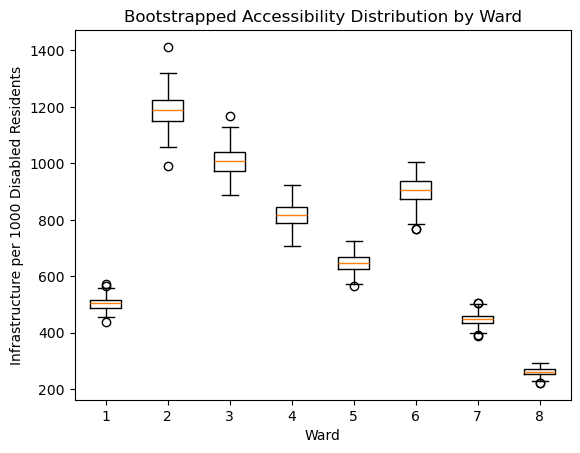

In [98]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.merge(infra, acs, on="ward")

df["ward"] = df["ward"].astype(int)
df["disabled_pop"] = df["DP02_0072E"].astype(float)
df["infra_per_1000_disabled"] = (df["total_infra"] / df["disabled_pop"]) * 1000

np.random.seed(42)

box_data = []
wards_sorted = sorted(df["ward"].unique())

for w in wards_sorted:
    row = df[df["ward"] == w].iloc[0]

    simulated = np.random.normal(
        loc=row["infra_per_1000_disabled"],
        scale=row["infra_per_1000_disabled"] * 0.05,
        size=200)

    box_data.append(simulated)

plt.figure()
plt.boxplot(box_data)

plt.xticks(range(1, len(wards_sorted) + 1), wards_sorted)
plt.xlabel("Ward")
plt.ylabel("Infrastructure per 1000 Disabled Residents")
plt.title("Bootstrapped Accessibility Distribution by Ward")

plt.show()